In [66]:
from droste import droste, search_magenta
import io
import cairosvg
from skimage.transform import warp_polar, rotate, rescale
from skimage.util import img_as_float

import matplotlib.pyplot as plt
import numpy as np
import cv2

In [43]:
image = cairosvg.svg2png(url = "../matte_framed_magenta.svg")
image = Image.open(io.BytesIO(image))

if image.mode == "RGBA":
    magenta = (255, 0, 255, 255)
elif image.mode == "RGB":
    magenta = (255, 0, 255)
    
left, right, top, bottom = search_magenta(image, magenta)
image = droste(image, 5)

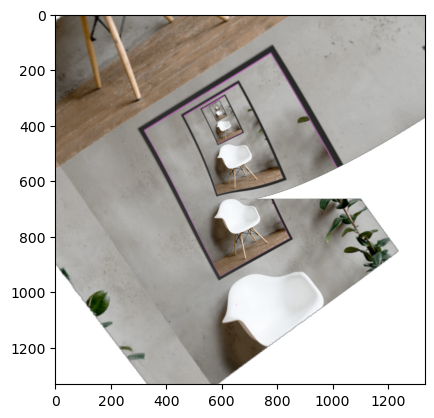

In [179]:
arr_image = img_as_float(image)

h, w = arr_image.shape[:2]

center = (h // 2, w // 2)

magenta_center = ((top+bottom) // 2, (left + right) //2)

dx = center[1] - magenta_center[1]
dy = center[0] - magenta_center[0]

arr_image = np.roll(arr_image, (dy, dx), axis = (0, 1))


M = h / np.log(h)

arr_image = cv2.logPolar(
    arr_image,
    center = center,
    M = M,
    flags = cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS
)

arr_image = np.roll(arr_image, arr_image.shape[1]//100, axis=1)
mat = cv2.getRotationMatrix2D(center, 10, 1.0)


arr_image= cv2.warpAffine(arr_image, mat, (w, h))


arr_image = cv2.logPolar(
    arr_image,
    center = center,
    M = M,
    flags = cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP
)

plt.imshow(arr_image)
plt.show()